Data Quality Autopsy: Hospital Readmission Dataset
Objective

This notebook performs a systematic data quality assessment of the Diabetes 130-US Hospitals (1999–2008) dataset.
The goal is to evaluate whether the dataset is suitable for statistical analysis and predictive modeling in the context of hospital readmission risk, and to identify risks that could lead to biased or misleading conclusions if ignored.

Decision context:
Hospital administrators aim to reduce avoidable readmissions while minimizing patient harm and operational costs.
Poor data quality at this stage could result in incorrect risk estimates, unfair patient treatment, or unsafe automation decisions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


In [2]:
data_path = "C:/Users/user/Downloads/project-1-data-science/data/raw/diabetic_data.csv"
df = pd.read_csv(data_path)

df.head()


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


Target Variable: Readmission

The target variable indicates whether a patient was readmitted within a certain time window.
Understanding its distribution is essential before any modeling decisions.

In [3]:

df['readmitted'].value_counts(normalize=True)


readmitted
NO     0.539119
>30    0.349282
<30    0.111599
Name: proportion, dtype: float64

Which class is dominant?

Is the target naturally binary or multiclass?

What immediate risk does this distribution pose for predictive modeling?
The target variable is multiclass, with a strong dominance of the NO category, although conceptually the problem can be framed as binary (readmitted versus not readmitted). This imbalance introduces immediate modeling risks, including biased predictions toward the majority class and misleading accuracy-based evaluation, which can obscure poor performance on clinically important minority outcomes.


Missing Data Assessment

Missing values in healthcare datasets are rarely random.
They often reflect operational constraints, undocumented procedures, or systemic bias.
This section identifies both explicit and implicit missing values.

In [4]:
df.isna().sum().sort_values(ascending=False)
(df.isna().sum() / len(df)).sort_values(ascending=False)

max_glu_serum               0.947468
A1Cresult                   0.832773
encounter_id                0.000000
nateglinide                 0.000000
glimepiride                 0.000000
acetohexamide               0.000000
glipizide                   0.000000
glyburide                   0.000000
tolbutamide                 0.000000
pioglitazone                0.000000
rosiglitazone               0.000000
acarbose                    0.000000
miglitol                    0.000000
troglitazone                0.000000
tolazamide                  0.000000
examide                     0.000000
citoglipton                 0.000000
insulin                     0.000000
glyburide-metformin         0.000000
glipizide-metformin         0.000000
glimepiride-pioglitazone    0.000000
metformin-rosiglitazone     0.000000
metformin-pioglitazone      0.000000
change                      0.000000
diabetesMed                 0.000000
chlorpropamide              0.000000
repaglinide                 0.000000
p

In [5]:
(df.isna().sum() / len(df)).sort_values(ascending=False)


max_glu_serum               0.947468
A1Cresult                   0.832773
encounter_id                0.000000
nateglinide                 0.000000
glimepiride                 0.000000
acetohexamide               0.000000
glipizide                   0.000000
glyburide                   0.000000
tolbutamide                 0.000000
pioglitazone                0.000000
rosiglitazone               0.000000
acarbose                    0.000000
miglitol                    0.000000
troglitazone                0.000000
tolazamide                  0.000000
examide                     0.000000
citoglipton                 0.000000
insulin                     0.000000
glyburide-metformin         0.000000
glipizide-metformin         0.000000
glimepiride-pioglitazone    0.000000
metformin-rosiglitazone     0.000000
metformin-pioglitazone      0.000000
change                      0.000000
diabetesMed                 0.000000
chlorpropamide              0.000000
repaglinide                 0.000000
p

In [6]:
(df == '?').sum().sort_values(ascending=False)


weight                      98569
medical_specialty           49949
payer_code                  40256
race                         2273
diag_3                       1423
diag_2                        358
diag_1                         21
encounter_id                    0
tolazamide                      0
glyburide                       0
tolbutamide                     0
pioglitazone                    0
rosiglitazone                   0
acarbose                        0
miglitol                        0
troglitazone                    0
citoglipton                     0
examide                         0
acetohexamide                   0
insulin                         0
glyburide-metformin             0
glipizide-metformin             0
glimepiride-pioglitazone        0
metformin-rosiglitazone         0
metformin-pioglitazone          0
change                          0
diabetesMed                     0
glipizide                       0
repaglinide                     0
glimepiride   

In [7]:
((df == '?').sum() / len(df)).sort_values(ascending=False)


weight                      0.968585
medical_specialty           0.490822
payer_code                  0.395574
race                        0.022336
diag_3                      0.013983
diag_2                      0.003518
diag_1                      0.000206
encounter_id                0.000000
tolazamide                  0.000000
glyburide                   0.000000
tolbutamide                 0.000000
pioglitazone                0.000000
rosiglitazone               0.000000
acarbose                    0.000000
miglitol                    0.000000
troglitazone                0.000000
citoglipton                 0.000000
examide                     0.000000
acetohexamide               0.000000
insulin                     0.000000
glyburide-metformin         0.000000
glipizide-metformin         0.000000
glimepiride-pioglitazone    0.000000
metformin-rosiglitazone     0.000000
metformin-pioglitazone      0.000000
change                      0.000000
diabetesMed                 0.000000
g

Which variables contain the highest proportion of '?' values?

Why is this more dangerous than standard NaN values?

What risk does this pose if these variables are used in modeling without correction?
  
     bd m answer hoga

In [8]:
df.replace('?', np.nan, inplace=True)
(df.isna().sum() / len(df)).sort_values(ascending=False)


weight                      0.968585
max_glu_serum               0.947468
A1Cresult                   0.832773
medical_specialty           0.490822
payer_code                  0.395574
race                        0.022336
diag_3                      0.013983
diag_2                      0.003518
diag_1                      0.000206
encounter_id                0.000000
troglitazone                0.000000
tolbutamide                 0.000000
pioglitazone                0.000000
rosiglitazone               0.000000
acarbose                    0.000000
miglitol                    0.000000
citoglipton                 0.000000
tolazamide                  0.000000
examide                     0.000000
glipizide                   0.000000
insulin                     0.000000
glyburide-metformin         0.000000
glipizide-metformin         0.000000
glimepiride-pioglitazone    0.000000
metformin-rosiglitazone     0.000000
metformin-pioglitazone      0.000000
change                      0.000000
d

In [9]:
df.groupby('readmitted').apply(lambda x: x.isna().mean()).T.sort_values(by='NO', ascending=False)


C:\Users\user\AppData\Local\Temp\ipykernel_11648\2885371801.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby('readmitted').apply(lambda x: x.isna().mean()).T.sort_values(by='NO', ascending=False)


readmitted,<30,>30,NO
weight,0.968566,0.957519,0.975758
max_glu_serum,0.941798,0.945534,0.949894
A1Cresult,0.852426,0.836827,0.826079
medical_specialty,0.509025,0.512477,0.473024
payer_code,0.407414,0.389028,0.397364
race,0.016554,0.015136,0.028197
diag_3,0.008013,0.009509,0.018118
diag_2,0.002553,0.002082,0.004648
diag_1,0.000440,0.000113,0.000219
encounter_id,0.000000,0.000000,0.000000


### Leakage Risk Assessment

This section evaluates whether administrative variables encode post-outcome
information that could lead to target leakage in predictive modeling.


In [10]:
leakage_candidates = [
    'discharge_disposition_id',
    'admission_type_id',
    'admission_source_id'
]


In [11]:
df.groupby('readmitted')[leakage_candidates].mean()


,discharge_disposition_id,admission_type_id,admission_source_id
readmitted,,,
<30,4.468874,1.976490,5.821168
>30,3.363061,2.029034,5.965030
NO,3.788149,2.030585,5.604185


## Data Quality Decisions and Feature Triage
Based on the observed missingness patterns and their relationship with the target variable, features are categorized according to their data quality risk and analytical usefulness. Each category reflects a deliberate trade-off between information retention and bias prevention.

Features Removed Due to Extreme Systematic Missingness

These variables exhibit extreme levels of non-random missingness driven by administrative collection practices rather than patient characteristics. Retaining them would introduce institutional bias without meaningful predictive value.

In [12]:
to_drop = ['weight', 'payer_code', 'medical_specialty']
df = df.drop(columns=[c for c in to_drop if c in df.columns])


Features Retained with Explicit Missingness Encoding

For these variables, missingness itself carries potential information and may correlate with readmission outcomes. Rather than imputing immediately, missingness is explicitly encoded to preserve signal.

In [13]:
for col in ['diag_1', 'diag_2', 'diag_3', 'race']:
    if col in df.columns:
        df[col + '_missing'] = df[col].isna().astype(int)


 Low-Risk Features with Limited Missingness

Variables with low levels of missingness and weak class-dependent patterns are imputed using robust statistics to maintain distributional stability.

In [14]:
num_cols = df.select_dtypes(include='number').columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[num_cols].isna().sum().sum()



0

High-Quality Features Retained Without Modification

These variables are complete, consistently recorded, and directly relevant to patient outcomes. No transformation is applied to preserve original signal.

Target Leakage Risk Assessment

This section evaluates whether administrative and discharge-related variables
encode post-outcome information that could artificially inflate predictive
performance if used in modeling.

In [15]:
leakage_candidates = [
    'discharge_disposition_id',
    'admission_type_id',
    'admission_source_id'
]


In [16]:
df.groupby('readmitted')[leakage_candidates].mean()


,discharge_disposition_id,admission_type_id,admission_source_id
readmitted,,,
<30,4.468874,1.976490,5.821168
>30,3.363061,2.029034,5.965030
NO,3.788149,2.030585,5.604185


## Leakage Mitigation Decisions

Based on observed class separation and domain timing considerations, 
features that encode post-discharge or outcome-dependent information 
were excluded to prevent target leakage. Variables available at the 
time of admission were retained to preserve deployable signal.


In [17]:
df = df.drop(columns=['discharge_disposition_id'])


In [18]:
X = df.drop(columns='readmitted')
y = df['readmitted']


## Train–Test Split Strategy

A stratified split is used to preserve class distribution in both training
and test sets, ensuring fair evaluation under class imbalance.


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [20]:
y.value_counts(normalize=True), y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)


(readmitted
 NO     0.539119
 >30    0.349282
 <30    0.111599
 Name: proportion, dtype: float64,
 readmitted
 NO     0.539122
 >30    0.349285
 <30    0.111593
 Name: proportion, dtype: float64,
 readmitted
 NO     0.539108
 >30    0.349268
 <30    0.111624
 Name: proportion, dtype: float64)

In [21]:
cat_cols = X_train.select_dtypes(include='object').columns
cat_cols



Index(['race', 'gender', 'age', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum',
       'A1Cresult', 'metformin', 'repaglinide', 'nateglinide',
       'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide',
       'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
       'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton',
       'insulin', 'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed'],
      dtype='object')

In [22]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)


In [23]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

In [24]:
model_binary = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=120,
        max_depth=15,
        class_weight='balanced',
        n_jobs=-1,
        random_state=42
    ))
])

In [25]:
model_binary.fit(X_train, y_train_binary)

NameError: name 'y_train_binary' is not defined

In [ ]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))


C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

         <30       0.00      0.00      0.00      2272
         >30       0.56      0.01      0.01      7109
          NO       0.54      1.00      0.70     10973

    accuracy                           0.54     20354
   macro avg       0.37      0.34      0.24     20354
weighted avg       0.49      0.54      0.38     20354



C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
y_train_binary = y_train.replace({'<30':1, '>30':1, 'NO':0})
y_test_binary = y_test.replace({'<30':1, '>30':1, 'NO':0})

C:\Users\user\AppData\Local\Temp\ipykernel_11576\216673231.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_train_binary = y_train.replace({'<30':1, '>30':1, 'NO':0})
C:\Users\user\AppData\Local\Temp\ipykernel_11576\216673231.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_test_binary = y_test.replace({'<30':1, '>30':1, 'NO':0})


In [ ]:
y_proba = model_binary.predict_proba(X_test)[:, 1]

NotFittedError: Pipeline is not fitted yet.

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score

roc = roc_auc_score(y_test_binary, y_proba)
pr = average_precision_score(y_test_binary, y_proba)

print("ROC-AUC:", roc)
print("PR-AUC:", pr)

ROC-AUC: 0.684186853850153
PR-AUC: 0.6402246594304293


In [ ]:
import numpy as np
from sklearn.metrics import classification_report

for threshold in [0.30, 0.35, 0.40, 0.45, 0.50]:
    print(f"\nThreshold: {threshold}")
    y_pred_custom = (y_proba >= threshold).astype(int)
    print(classification_report(y_test_binary, y_pred_custom))


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.95      0.00      0.00     10973
           1       0.46      1.00      0.63      9381

    accuracy                           0.46     20354
   macro avg       0.71      0.50      0.32     20354
weighted avg       0.73      0.46      0.29     20354


Threshold: 0.35
              precision    recall  f1-score   support

           0       0.88      0.01      0.03     10973
           1       0.46      1.00      0.63      9381

    accuracy                           0.47     20354
   macro avg       0.67      0.51      0.33     20354
weighted avg       0.69      0.47      0.31     20354


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.82      0.09      0.16     10973
           1       0.48      0.98      0.64      9381

    accuracy                           0.50     20354
   macro avg       0.65      0.53      0.40     20354
weighted avg       0.66  

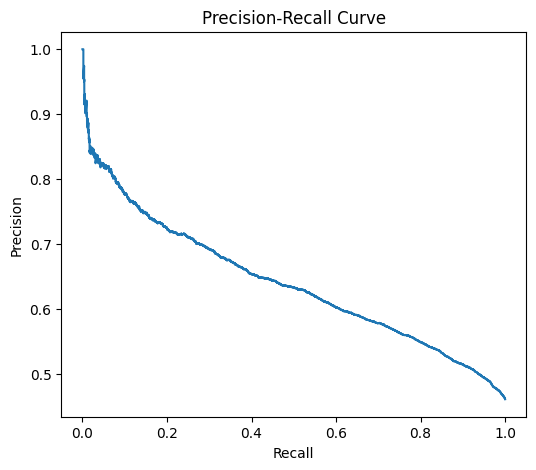

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test_binary, y_proba)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

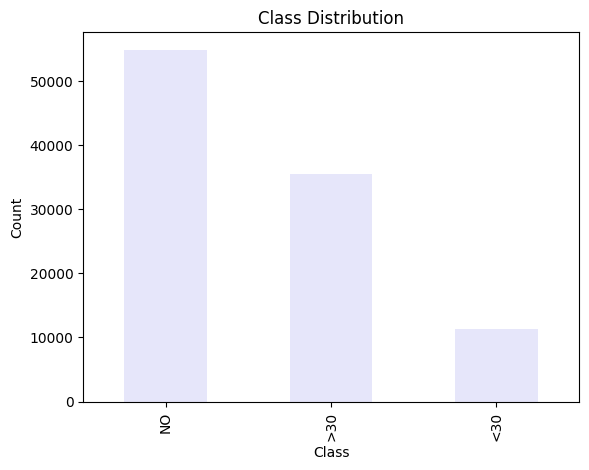

In [32]:
import matplotlib.pyplot as plt

df['readmitted'].value_counts().plot(kind='bar', color='lavender')
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

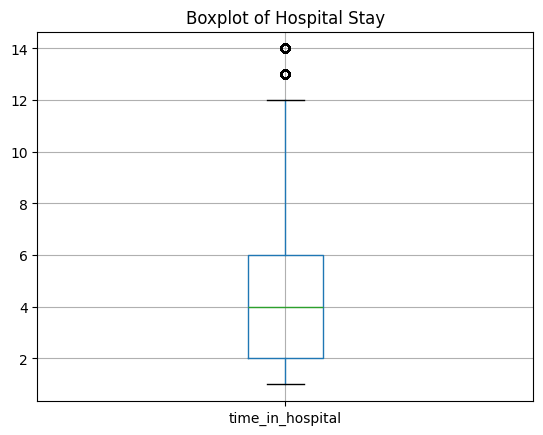

In [28]:
df.boxplot(column='time_in_hospital')
plt.title("Boxplot of Hospital Stay")
plt.show()

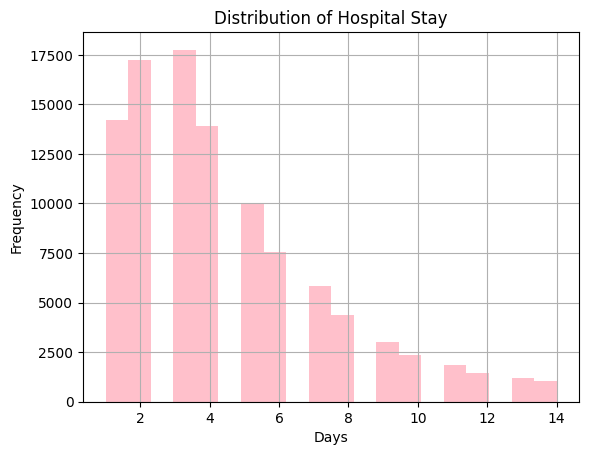

In [31]:
df['time_in_hospital'].hist(bins=20, color='pink')
plt.title("Distribution of Hospital Stay")
plt.xlabel("Days")
plt.ylabel("Frequency")
plt.show()